In [1]:
import matplotlib.pyplot as plt
import numpy as np

from mpl_toolkits.basemap import Basemap

import xarray as xr
import pandas as pd
import cmocean
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as colors

from mpl_toolkits.axes_grid1 import AxesGrid
from mpl_toolkits.basemap import Basemap
from scipy.optimize import curve_fit
from datetime import datetime

In [3]:
ds1 = xr.open_dataset('/media/athira/One Touch/pH_CMIP6/CMEMS/cmems_new/CMEMS_ph_mask.nc').squeeze()
ds2 = xr.open_dataset('/media/athira/One Touch/pH_CMIP6/SODA/SODA_new/SODA_ph_mask.nc').squeeze()

lat_range = slice(-30, 30) 
lon_range = slice(30, 120) 

ds3 = xr.open_dataset('pH_ensemble_ssp126_merged_r1.nc').squeeze()

subset_ds1 = ds1.sel(lat=lat_range, lon=lon_range)#.groupby('time.month').mean()
subset_ds2 = ds2.sel(lat=lat_range, lon=lon_range)#.groupby('time.month').mean()

subset_ds1['time'] = subset_ds1.indexes['time'].to_period('M').to_timestamp()
subset_ds2['time'] = subset_ds2.indexes['time'].to_period('M').to_timestamp()

# Interpolate ds2 onto ds1 grid (lat, lon, time)
subset_ds2_interp = subset_ds2.interp(
    lat=subset_ds1['lat'],
    lon=subset_ds1['lon'],
    time=subset_ds1['time'],
    method='linear'
)

# Calculate mean pH
mean_obs_pH = xr.concat(
    [subset_ds1['ph'], subset_ds2_interp['ph']],
    dim='model'
).mean(dim='model')



In [3]:
lat_range = slice(-30, 30)
lon_range = slice(30, 120)
month_ds2  = mean_obs_pH.sel(lat=lat_range, lon=lon_range, time=slice('1985', '2014')).groupby('time.month').mean()
month_ds3  = ds3.sel(lat=lat_range, lon=lon_range, time=slice('1985', '2014')).groupby('time.month').mean()



In [4]:
annual_ds2 = month_ds2.mean('month')
annual_ds3 = month_ds3.mean('month')

seasonal_ds2 = month_ds2 - annual_ds2
seasonal_ds3 = month_ds3 - annual_ds3

In [16]:
lat_range_as = slice(0, 30)
lon_range_as = slice(38, 78)

lat_range_bob = slice(0, 30)
lon_range_bob = slice(78, 120)

lat_range_cio = slice(-18, 0)
lon_range_cio = slice(30, 120)

lat_range_sio = slice(-30, -18)
lon_range_sio = slice(30, 120)

# as_ds1  = seasonal_ds1.sel(lat=lat_range_as, lon=lon_range_as).mean(['lat', 'lon'])
# bob_ds1  = seasonal_ds1.sel(lat=lat_range_bob, lon=lon_range_bob).mean(['lat', 'lon'])
# cio_ds1  = seasonal_ds1.sel(lat=lat_range_cio, lon=lon_range_cio).mean(['lat', 'lon'])
# sio_ds1  = seasonal_ds1.sel(lat=lat_range_sio, lon=lon_range_sio).mean(['lat', 'lon'])
as_ds2  = seasonal_ds2.sel(lat=lat_range_as, lon=lon_range_as).mean(['lat', 'lon'])
bob_ds2  = seasonal_ds2.sel(lat=lat_range_bob, lon=lon_range_bob).mean(['lat', 'lon'])
cio_ds2  = seasonal_ds2.sel(lat=lat_range_cio, lon=lon_range_cio).mean(['lat', 'lon'])
sio_ds2  = seasonal_ds2.sel(lat=lat_range_sio, lon=lon_range_sio).mean(['lat', 'lon'])

as_ds3  = seasonal_ds3.sel(lat=lat_range_as, lon=lon_range_as).mean(['lat', 'lon'])
bob_ds3  = seasonal_ds3.sel(lat=lat_range_bob, lon=lon_range_bob).mean(['lat', 'lon'])
cio_ds3  = seasonal_ds3.sel(lat=lat_range_cio, lon=lon_range_cio).mean(['lat', 'lon'])
sio_ds3  = seasonal_ds3.sel(lat=lat_range_sio, lon=lon_range_sio).mean(['lat', 'lon'])

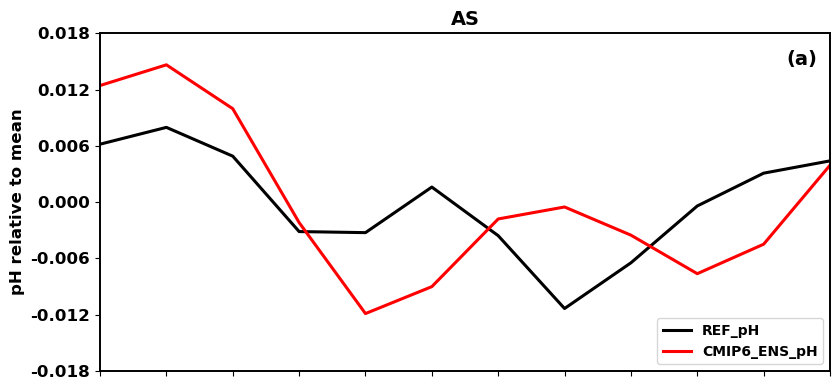

In [17]:

# as_ds2 = as_ds2['ph']
as_ds3 = as_ds3['ph']


months = np.arange(12)

xtick_locs = np.arange(12)

plt.figure(figsize=(8.5, 4))

plt.plot(months, as_ds2, '-', label='REF_pH', color='black', linewidth=2.2)
plt.plot(months, as_ds3, '-', label='CMIP6_ENS_pH', color='red', linewidth=2.2)

plt.grid(False)

# Show only tick marks (no labels)
plt.xticks(ticks=xtick_locs, labels=[])

yticks = [0.018, 0.012, 0.006, 0, -0.006, -0.012, -0.018]
plt.yticks(ticks=yticks, labels=[f'{y:.3f}' for y in yticks],
           fontsize=12, fontweight='bold')

plt.xlim(0, 11)
plt.ylim(min(yticks), max(yticks))

plt.ylabel('pH relative to mean', fontweight='bold', fontsize=12)
plt.title('AS', fontweight='bold', fontsize=14)

# Bold plot box
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(1.4)

ax.text(0.94, 0.95, '(a)',
        transform=ax.transAxes,
        fontsize=14, fontweight='bold',
        va='top')
plt.legend(fontsize=14, prop={'weight': 'bold'}, loc='lower right')

plt.tight_layout()

plt.savefig('monthly_cycle_AS_pH_f1.png', bbox_inches='tight', dpi=600)

plt.show()

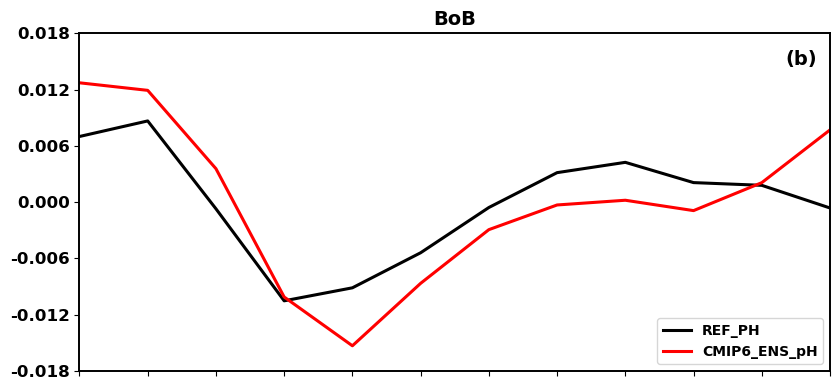

In [10]:
# bob_ds2 = bob_ds2['ph']
bob_ds3 = bob_ds3['ph']

months = np.arange(12)

xtick_locs = np.arange(12)

# Set up the plot
plt.figure(figsize=(8.5, 4))

plt.plot(months, bob_ds2, '-', label='REF_PH', color='black', linewidth=2.2)
plt.plot(months, bob_ds3, '-', label='CMIP6_ENS_pH', color='red', linewidth=2.2)


plt.grid(False)

plt.xticks(ticks=xtick_locs, labels=[])
# plt.xticks(ticks=xtick_locs, labels=xtick_labels, fontsize=12, fontweight='bold')
yticks = [0.018, 0.012, 0.006, 0, -0.006, -0.012, -0.018]
plt.yticks(ticks=yticks, labels=[f'{y:.3f}' for y in yticks], fontsize=12, fontweight='bold')

plt.xlim(0, 11)
plt.ylim(min(yticks), max(yticks))
# plt.ylabel('pH relative to mean', fontweight='bold', fontsize=12)
plt.title('BoB', fontweight='bold', fontsize=14)

ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(1.4)

ax.text(0.94, 0.95, '(b)',
        transform=ax.transAxes,
        fontsize=14, fontweight='bold',
        va='top')

plt.legend(fontsize=14, prop={'weight': 'bold'}, loc='lower right')

plt.tight_layout()

plt.savefig('monthly_cycle_BoB_pH_f1.png', bbox_inches = 'tight', dpi = 600)

plt.show()

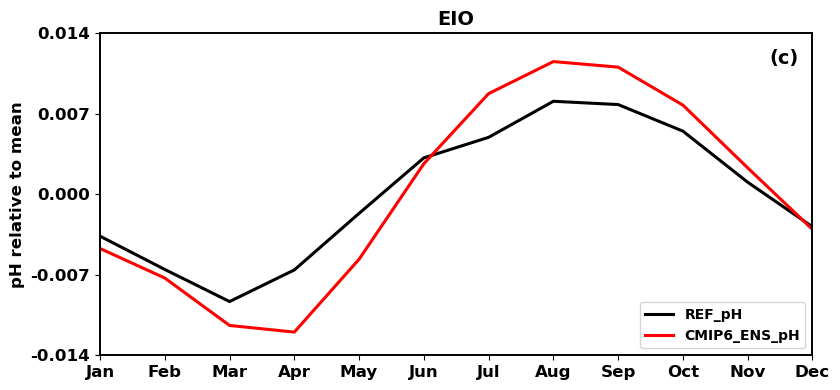

In [12]:

# cio_ds2 = cio_ds2['ph']
cio_ds3 = cio_ds3['ph']

months = np.arange(12)

xtick_locs = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
xtick_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
plt.figure(figsize=(8.5, 4))
plt.plot(months, cio_ds2, '-', label='REF_pH', color='black', linewidth=2.2)
plt.plot(months, cio_ds3, '-', label='CMIP6_ENS_pH', color='red', linewidth=2.2)

plt.grid(False)
plt.xticks(ticks=xtick_locs, labels=xtick_labels, fontsize=12, fontweight='bold')
yticks = [0.014, 0.007, 0, -0.007, -0.014]
plt.yticks(ticks=yticks, labels=[f'{y:.3f}' for y in yticks], fontsize=12, fontweight='bold')

plt.xlim(0, 11)
plt.ylim(min(yticks), max(yticks))

# Labels and layout
plt.ylabel('pH relative to mean', fontweight='bold', fontsize=12)
plt.title('EIO', fontweight='bold',fontsize=14)


ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(1.4)

ax.text(0.94, 0.95, '(c)',
        transform=ax.transAxes,
        fontsize=14, fontweight='bold',
        va='top')

plt.legend(fontsize=14, prop={'weight': 'bold'}, loc='lower right')

plt.tight_layout()

plt.savefig('monthly_cycle_EIO_pH_f1.png', bbox_inches = 'tight', dpi = 600)

plt.show()


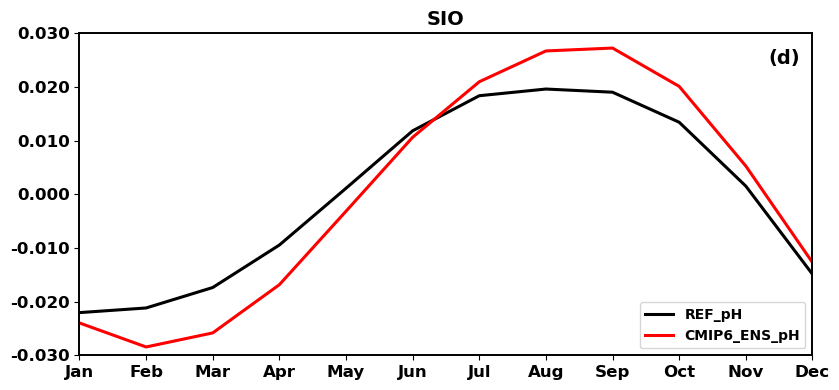

In [13]:

# sio_ds2 = sio_ds2['ph']
sio_ds3 = sio_ds3['ph']

months = np.arange(12)
xtick_locs = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
xtick_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
plt.figure(figsize=(8.5, 4))

plt.plot(months, sio_ds2, '-', label='REF_pH', color='black', linewidth=2.2)
plt.plot(months, sio_ds3, '-', label='CMIP6_ENS_pH', color='red', linewidth=2.2)

plt.grid(False)
plt.xticks(ticks=xtick_locs, labels=xtick_labels, fontsize=12, fontweight='bold')
yticks = [-0.03, -0.02, -0.01, 0, 0.01, 0.02, 0.03]
plt.yticks(ticks=yticks, labels=[f'{y:.3f}' for y in yticks], fontsize=12, fontweight='bold')

plt.xlim(0, 11)
plt.ylim(min(yticks), max(yticks))

# Labels and layout
# plt.ylabel('pH relative to mean', fontweight='bold', fontsize=12)
plt.title('SIO', fontweight='bold', fontsize=14)

ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(1.4)
    
ax.text(0.94, 0.95, '(d)',
        transform=ax.transAxes,
        fontsize=14, fontweight='bold',
        va='top')

plt.legend(fontsize=14, prop={'weight': 'bold'}, loc='lower right')

plt.tight_layout()

plt.savefig('monthly_cycle_SIO_pH_f1.png', bbox_inches = 'tight', dpi = 600)

plt.show()
